# 2. Feature extraction

In [1]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

## 2.1. Dataset - Binary Drone Audio 

In [16]:
def plot_mfcc(audio_path):
    # Load the audio file
    y, sr = librosa.load(audio_path)

    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    # Plot MFCCs
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC')
    plt.xlabel('Time')
    plt.ylabel('MFCC Coefficient')
    plt.show()

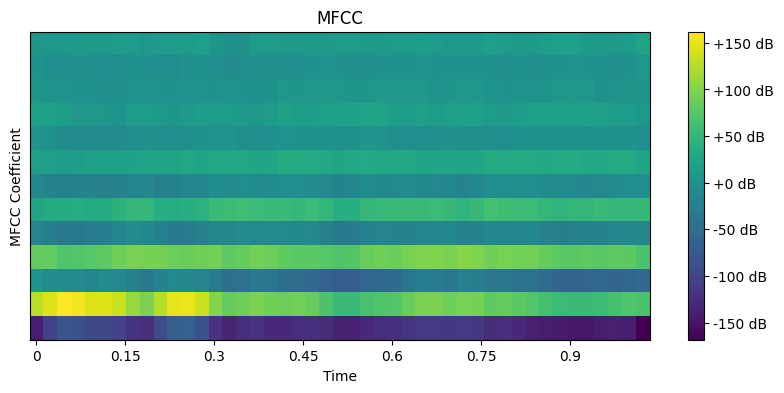

In [20]:
# Example usage - yes_drone
audio_file_path = "data/DroneAudioDataset-master/Binary_Drone_Audio/yes_drone/B_S2_D1_067-bebop_000_.wav"
plot_mfcc(audio_file_path)

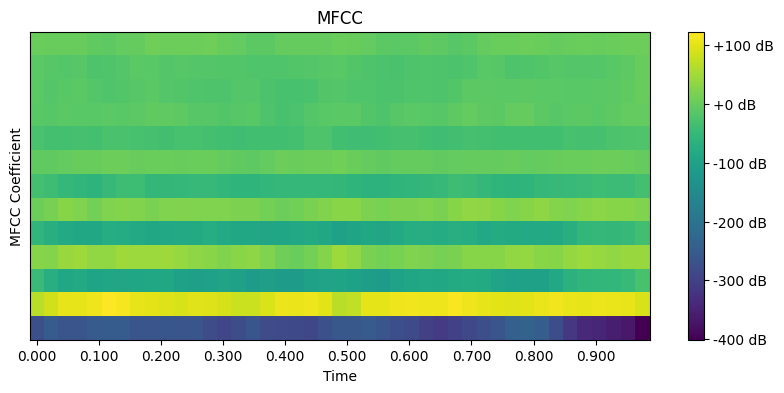

In [21]:
# Example usage - unknown
audio_file_path = "data/DroneAudioDataset-master/Binary_Drone_Audio/unknown/1-7973-A-7_1002.wav"
plot_mfcc(audio_file_path)

In [27]:
def extract_features_from_folder(folder_path, label, min_length=2048):
    X = []
    y = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):
            file_path = os.path.join(folder_path, filename)
            try:
                audio, sr = librosa.load(file_path)
                
                # Skip if too short
                if len(audio) < min_length:
                    print(f"Skipping {filename}, too short: {len(audio)} samples")
                    continue

                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
                mfcc_mean = np.mean(mfcc, axis=1)
                
                X.append(mfcc_mean)
                y.append(label)
            except Exception as e:
                print(f"Failed to process {file_path}: {e}")
    
    return X, y


In [28]:
yes_path = "data/DroneAudioDataset-master/Binary_Drone_Audio/yes_drone"
unknown_path = "data/DroneAudioDataset-master/Binary_Drone_Audio/unknown"

X_yes, y_yes = extract_features_from_folder(yes_path, label=1)
X_unk, y_unk = extract_features_from_folder(unknown_path, label=0)

# Combine
X = np.array(X_yes + X_unk)
y = np.array(y_yes + y_unk)


Skipping doing_the_dishes019.wav, too short: 1745 samples
Skipping silence300.wav, too short: 34 samples


## 2.2. Dataset - Drone Print